# Artifact-Based Plotting Demo

The following cells demonstrate the new artifact-based plotting workflow:
1. **Generate data** using scripts (one-time)
2. **Plot from saved artifacts** (fast, reproducible)

In [1]:
# Setup: autoreload for development (optional)
try:
    from IPython import get_ipython
    ipython = get_ipython()
    if ipython:
        ipython.run_line_magic('load_ext', 'autoreload')
        ipython.run_line_magic('autoreload', '2')
except Exception:
    pass  # Autoreload not available, continue without it

In [2]:
# Reload modules to pick up changes
import importlib
import spins_sdp.sdp
import spins_sdp.pauli
importlib.reload(spins_sdp.sdp)
importlib.reload(spins_sdp.pauli)

import plots
from spins_sdp.scripts import exact_ground_energy, npa_energy_lb
from spins_sdp.utils import iter_result_runs, format_result_runs_table

## Step 1: Generate Artifacts (Run Once)

These scripts compute exact ground energies and SDP lower bounds, saving results to disk.
Re-running with `--resume` only computes missing N values.

In [20]:
# Generate exact ground energies for the Ising model
exact_ground_energy.main([
    "--model", "heisenberg",
    "--N-min", "9",
    "--N-max", "15",
    #"--J", "1", "--h", "0.7", "--k", "0.3",
    "--boundary", "periodic",
    "--resume",
])

Wrote results to: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/spins_sdp/results/spin_exact_ground_energy/v1/aadfb1b072afee7f


0

In [4]:
# Generate SDP lower bounds (with all symmetries for Heisenberg)
npa_energy_lb.main([
    "--model", "heisenberg",
    "--basis", "heisenberg_simple",
    #"--npa-level", "2",
    "--N-min", "2",
    "--N-max", "15",
    "--boundary", "periodic",
    "--resume",
    "--use-all-symmetries",  # Enable all symmetries for Heisenberg
])

Moment relaxation sweep:   0%|          | 0/14 [00:00<?, ?it/s, N=2, done=0, total=14]

Moment relaxation sweep: 100%|██████████| 14/14 [02:16<00:00,  9.72s/it, N=15, done=13, total=14]

Wrote results to: /users/eleves-b/2023/sherab-losel.matos/thesis/SpinsSDP/SpinsSDP/spins_sdp/results/spin_moment_energy_lb/v1/ba7bdcff68936d5d


0

## Step 2: List Available Runs

Use the `list_runs` utilities to see what artifacts are stored.

In [7]:
# View stored exact ground energy runs
from spins_sdp.utils import list_exact_runs
list_exact_runs()

artifact               v   hash             max_N updated_at           model          boundary  basis              npa_k 
-------------------------------------------------------------------------------------------------------------------------
spin_exact_ground_ene… v1  f0e28cf3d0e38590 12    2026-02-09T12:36:37Z ising          periodic                           


In [31]:
# View stored NPA lower bound runs
from spins_sdp.utils import list_lb_runs
list_lb_runs()

artifact               v   hash             max_N updated_at           model          boundary  basis              npa_k 
-------------------------------------------------------------------------------------------------------------------------
spin_moment_energy_lb  v1  3da868cadebd93f5 15    2026-02-10T12:58:59Z heisenberg     periodic  npa                2     
spin_moment_energy_lb  v1  979999e4ce62e6ce 15    2026-02-10T12:58:16Z heisenberg     periodic  heisenberg_simple        
spin_moment_energy_lb  v1  dd36624dc568c0ae 15    2026-02-10T12:30:57Z heisenberg     periodic  heisenberg_simple        
spin_moment_energy_lb  v1  b41a6e25e861293b 15    2026-02-10T12:29:06Z heisenberg     periodic  npa                2     
spin_moment_energy_lb  v1  ecfbd834ea32f4ef 10    2026-02-10T11:21:27Z heisenberg     periodic  npa                3     


## Step 3: Plot from Artifacts

The artifact-based plotting functions load data from saved runs.

### Comparing Exact vs SDP Lower Bound

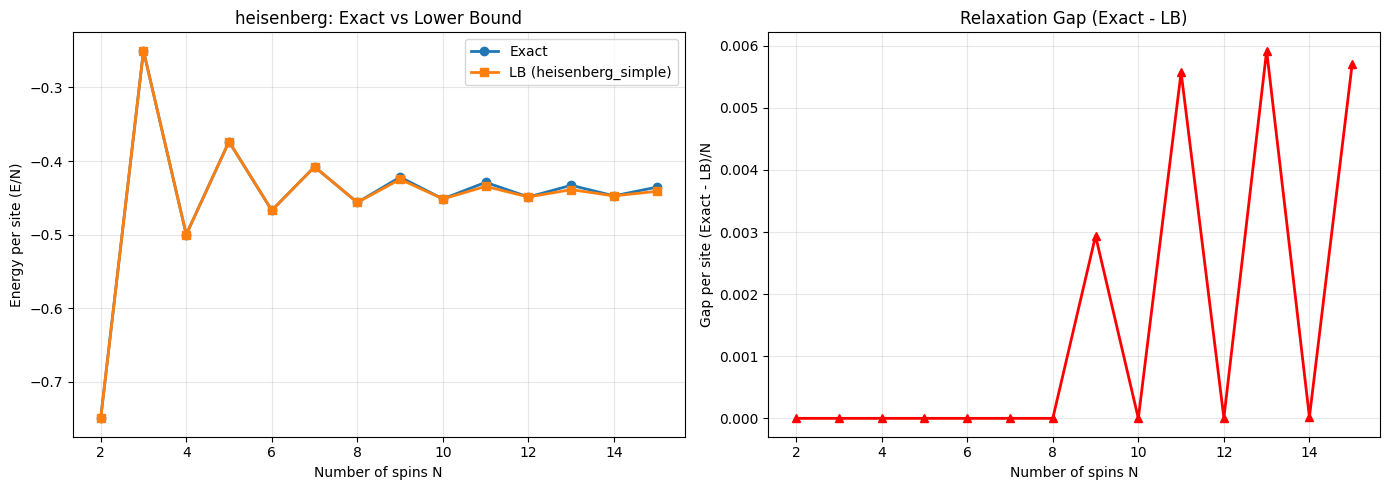

In [5]:
# Plot exact vs NPA lower bound for the Ising model
# Uses parameter-based lookup to find matching artifacts
from plots import plot_exact_vs_lb

_ = plot_exact_vs_lb(
    model="heisenberg",
    model_params={}, #{"J": 1.0, "h": 0.7, "k": 0.3},
    boundary="periodic",
    lb_basis="heisenberg_simple",
    per_site=True,
)

### Utility Plots (Computed On-the-Fly)

Some plotting utilities perform quick computations directly without needing stored artifacts.

In [ ]:
# NPA basis size heatmap: visualize how basis size scales with N and NPA level
from plots import npa_basis_size_heatmap

_ = npa_basis_size_heatmap(N_max=20, npa_level_max=2)

In [ ]:
# Compare basis sizes across different methods
from plots import plot_basis_size_comparison

_ = plot_basis_size_comparison(
    N_values=range(2, 10),
    npa_levels=[1, 2],
    include_paper_basis=True,
)

## Runtime Comparison

Compare solve times between exact diagonalization and SDP relaxation.

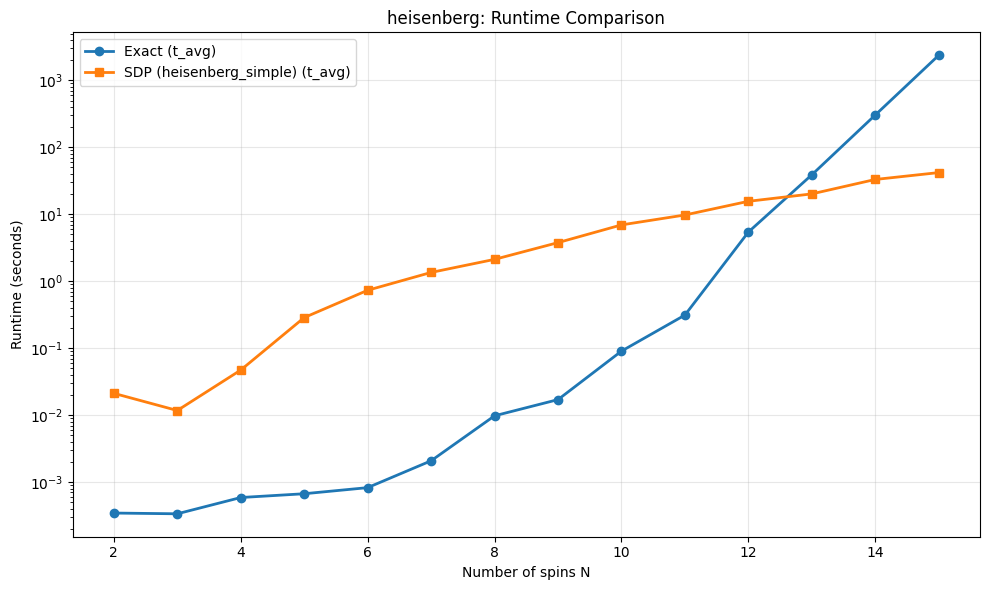

In [6]:
# Plot runtime comparison: Exact diagonalization vs SDP
from plots import plot_runtime_comparison

_ = plot_runtime_comparison(
    model="heisenberg",
    model_params={},#{"J": 1.0, "h": 0.7, "k": 0.3},
    boundary="periodic",
    lb_basis="heisenberg_simple",
    npa_levels=[2],
    use="t_avg",
    logy=True,
)

## Heisenberg-J₂ Sweep Demo

The `plot_heisenberg_j2_sweep` function plots energy vs J₂ coupling for a fixed N.
First, we need to generate the artifacts for multiple J₂ values.

In [13]:
# Generate Heisenberg-J2 exact ground energies for several J2 values (N=4, small for demo)
J2_values = [0.0, 0.3, 0.5, 0.7, 1.0, 1.3, 1.5]

for J2 in J2_values:
    exact_ground_energy.main([
        "--model", "heisenberg_j2",
        "--N-min", "4",
        "--N-max", "4",
        "--J2", str(J2),
        "--boundary", "periodic",
        "--resume",
    ])

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\2b91e99e24e6095a
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\af44b6816fc66636
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\04c74a7ae54a1815
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\d5681820b0b0e7ca
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\8b64f864e20d738e
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\b600d698458f7bca
Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_exact_ground_energy\v1\b452107f935791bc


In [ ]:
# Generate SDP lower bounds for the Heisenberg-J2 model (with all symmetries)
# Using heisenberg_j2_weak basis for J2 <= 1.0, heisenberg_j2_strong for J2 > 1.0

for J2 in J2_values:
    basis = "heisenberg_j2_weak" if J2 <= 1.0 else "heisenberg_j2_strong"
    npa_energy_lb.main([
        "--model", "heisenberg_j2",
        "--basis", basis,
        "--N-min", "4",
        "--N-max", "4",
        "--J2", str(J2),
        "--boundary", "periodic",
        "--resume",
        "--use-all-symmetries",  # Enable all symmetries for Heisenberg
    ])

Moment relaxation sweep: 100%|██████████| 1/1 [00:00<00:00, 11.25it/s, N=4, done=0, total=1]


Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\846e9dcc176708f3


Moment relaxation sweep: 100%|██████████| 1/1 [00:00<00:00, 12.33it/s, N=4, done=0, total=1]


Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\465679cc0e36d92c


Moment relaxation sweep: 100%|██████████| 1/1 [00:00<00:00, 11.89it/s, N=4, done=0, total=1]


...

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\d0b4419fa6b6e0d3


Moment relaxation sweep: 100%|██████████| 1/1 [00:00<00:00, 18.54it/s, N=4, done=0, total=1]


Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\15ae3def069ac7a7


Moment relaxation sweep: 100%|██████████| 1/1 [00:00<00:00, 21.53it/s, N=4, done=0, total=1]

Wrote results to: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_moment_energy_lb\v1\8f8044f3ffa88392


In [ ]:
# Plot Heisenberg-J2 sweep
from plots import plot_heisenberg_j2_sweep

_ = plot_heisenberg_j2_sweep(
    N=4,
    J2_values=J2_values,
    boundary="periodic",
    per_site=True,
)

## Summary (Exact & SDP Artifacts)

General workflow for exact/SDP results:

1. **Generate Artifacts** – Run scripts (`exact_ground_energy`, `npa_energy_lb`) to compute and save results with `--resume` for incremental updates.
2. **List Runs** – Use `list_exact_runs()` and `list_lb_runs()` to inspect stored data.
3. **Plot from Artifacts** – Call plotting functions to visualize results without recomputation:
   - `plot_exact_vs_lb()` – Compare exact vs SDP lower bound
   - `plot_runtime_comparison()` – Compare solve times
   - `plot_heisenberg_j2_sweep()` – Energy vs J₂ coupling
4. **Utility Plots** – Quick on-the-fly visualizations:
   - `npa_basis_size_heatmap()` – Heatmap of basis sizes
   - `plot_basis_size_comparison()` – Compare basis methods

---

# Optimization Sweep Demo

This section demonstrates the **optimization sweep** functionality, which uses the optimization package to find optimal subsets of monomials to add to a starting NPA basis.

## The Problem

Given:
- A **starting set** of monomials (e.g., NPA level 1)
- An **adding set** of candidate monomials (difference between NPA level 2 and level 1)
- A **Hamiltonian** to minimize

We want to find which **k monomials** from the adding set give the best SDP lower bound.

This is a combinatorial optimization problem with $\binom{L}{k}$ possible choices, where $L = |\text{adding set}|$.

## Symmetry Options

For the **Heisenberg model**, we can exploit multiple symmetries to speed up SDP solves:

| Flag | Effect |
|------|--------|
| `--use-real-operator` | Restrict to real moments (Heisenberg H is real) |
| `--use-rotation` | Block-diagonalize by Pauli signature |
| `--use-sign-symmetry` | Zero out sign-variant moments |
| `--use-permutation` | Group by X↔Y↔Z relabeling |
| `--use-translation` | Group by cyclic translation (periodic BC) |
| `--use-mirror` | Group by spatial reflection |
| `--use-all-symmetries` | Enable all of the above |

Using `--use-all-symmetries` gives exponential speedups for Heisenberg chains.

## Step 1: Run an Optimization Sweep

The `optimization_sweep` script runs Monte Carlo optimization for multiple values of k (number of monomials to add) and multiple random seeds, saving all results to disk.

### CLI Usage

```bash
# Basic usage with simulated annealing
python -m spins_sdp.scripts.optimization_sweep \
    --model heisenberg --N 4 --boundary periodic \
    --start-level 1 --end-level 2 \
    --method sa --sa-steps 50 \
    --ks 0 1 2 3 4 5 \
    --seeds 42 43 44

# Or sweep k from 0 to k-max (inclusive)
python -m spins_sdp.scripts.optimization_sweep \
    --model heisenberg --N 4 --boundary periodic \
    --start-level 1 --end-level 2 \
    --method sa --sa-steps 50 \
    --k-max 10 --num-seeds 3
```

### Getting help (list all args)

To see all available command-line arguments (including `--method`-specific options), run:

```bash
python -m spins_sdp.scripts.optimization_sweep --help
# or
python -m spins_sdp.scripts.optimization_sweep -h
```

If you have multiple Python installations, make sure you’re using your project environment’s interpreter. In this repo that’s typically:

```bash
C:/.../code/SpinsSDP/.venv/Scripts/python.exe -m spins_sdp.scripts.optimization_sweep -h
```

### Programmatic Usage (in notebook)

In [ ]:
# Run optimization sweep programmatically with all Heisenberg symmetries enabled
from spins_sdp.scripts import optimization_sweep

# Run a small sweep with full symmetry exploitation
# Tip: add "--force" if you want to recompute and re-print stats even if already cached.
optimization_sweep.main([
    "--model", "heisenberg",
    "--N", "10",
    "--boundary", "periodic",
    "--start-level", "1",
    "--end-level", "2",
    "--end-basis", "heisenberg_simple",
    "--method", "pt",
    "--pt-epochs", "1",
    "--pt-steps-per-epoch", "10",
    # "--method", "bo",
    # "--bo-n-init", "20",
    # "--bo-n-iter", "20",
    # "--bo-candidates-per-iter", "20",
    "--ks", "10", "20", "40", "80", "100", "150", "200", "250", "300", "350", "400",
    "--num-seeds", "5",
    "--use-all-symmetries",
    "--feedback",
])

Model: heisenberg, N=10, boundary=periodic, end_basis=heisenberg_simple
Starting set size: 31, Adding set size: 1485, Final set size: 1516
Total jobs requested: 55, Already in artifact: 0, To compute now: 55


Optimization sweep:   0%|          | 0/55 [00:00<?, ?it/s, k=10, seed=42]/users/eleves-b/2023/sherab-losel.matos/miniconda3/lib/python3.13/multiprocessing/popen_fork.py:67: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Optimization sweep:  36%|███▋      | 20/55 [00:45<01:18,  2.25s/it, k=100, seed=42]


KeyboardInterrupt: 

## Step 2: List Available Optimization Runs

Use `list_optimization_runs()` to see what optimization sweeps are stored.

In [8]:
# List all optimization sweep runs
from plots import list_optimization_runs

runs = list_optimization_runs()

Hash               Model          N Method    L         k  Runs Updated             
--------------------------------------------------------------------------------
d281ed31b16b113d   heisenberg    10     pt  406   10..400    55 2026-02-09T13:20:58 
eaa617dbd2e9dec4   heisenberg    10 random  406   10..400   220 2026-02-09T13:30:30 
22789345a337f209   heisenberg    10     bo  405   10..400    55 2026-02-09T17:09:00 
61826619291e8b17   heisenberg    10     bo 20655   10..400    55 2026-02-09T15:25:56 
ccb9ea260ebbc6e1   heisenberg    10     pt 20656   10..400    55 2026-02-09T14:51:26 
a3019dc10ffb0081   heisenberg    10    rbm  405      2..6     6 2026-02-09T15:49:34 
87c75a62d96d2b80   heisenberg    10    rbm 20655    10..40    15 2026-02-09T15:57:19 
171af9d4638fce65   heisenberg    10    rbm  405   10..400    55 2026-02-09T17:35:45 
a2fe3aeb06739c9d   heisenberg    10     pt  405   10..400    55 2026-02-09T16:45:23 
6713b778763ea466   heisenberg    10     bo 1485   0..1485       20

## Step 3: Plot Optimization Results

### Main Plot: Lower Bound vs Number of Monomials

The primary visualization shows how the SDP lower bound improves as we add more monomials to the basis.

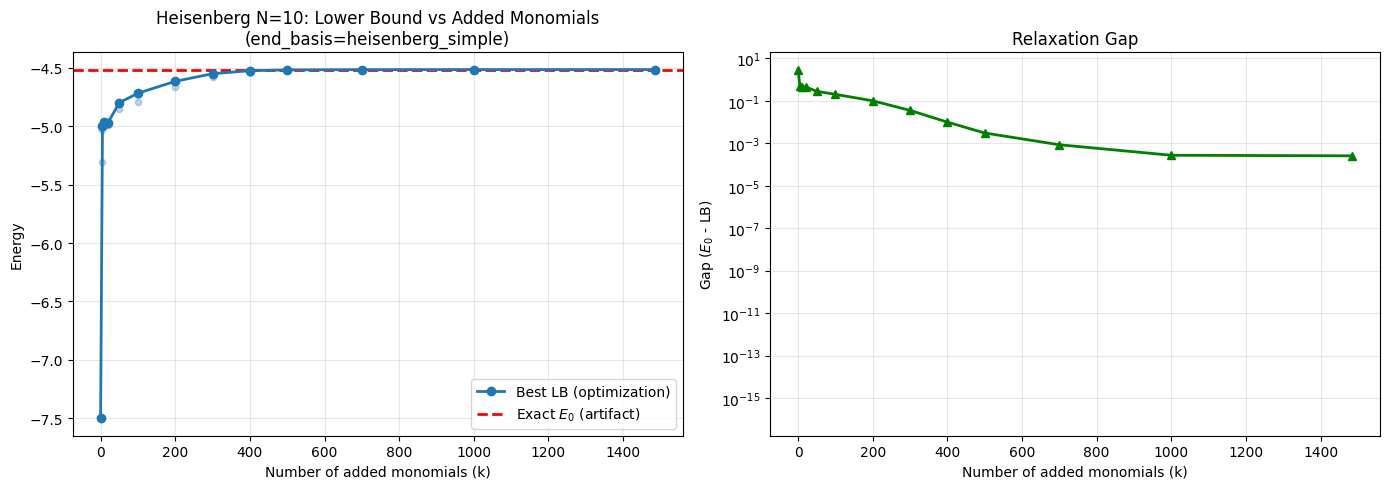

Adding set size (L): 1485


In [22]:
# Plot optimization sweep results
# The function automatically finds the exact ground state energy for comparison
from plots import plot_optimization_sweep

result = plot_optimization_sweep(
    model="heisenberg",
    N=10,
    boundary="periodic",
    start_level=1,
    end_level=2,
    end_basis="heisenberg_simple",
    method="rbm",
    show_seeds=True,  # Show individual seed results as scatter points
)

print(f"Adding set size (L): {result['L']}")

### Convergence Analysis

How quickly does the lower bound approach the full relaxation value as we add monomials?

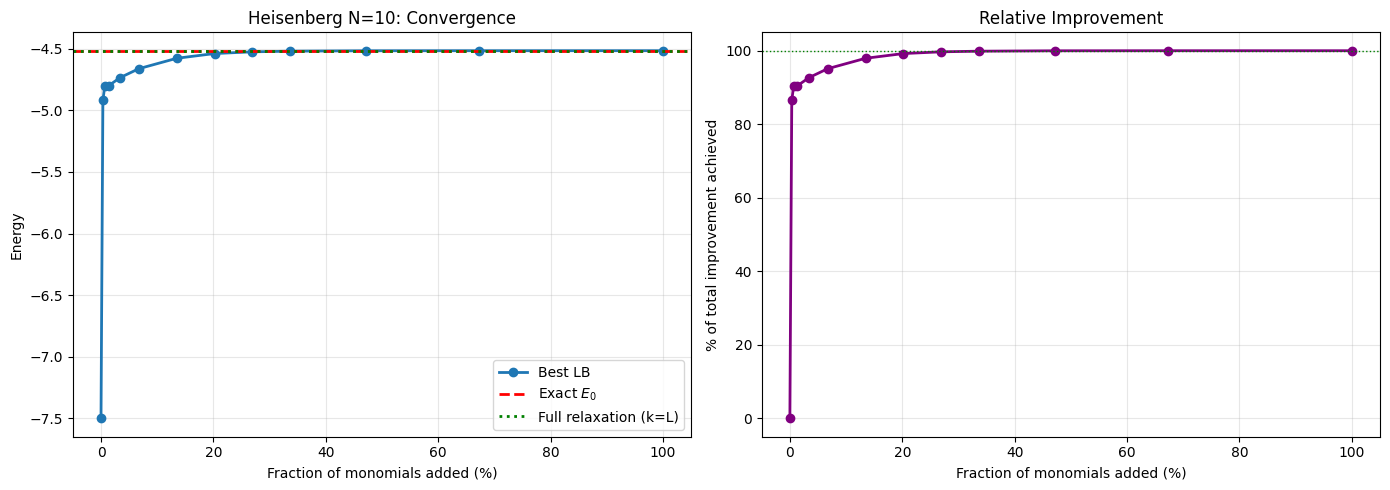

In [14]:
# Plot convergence: normalized improvement vs fraction of monomials
from plots import plot_optimization_convergence

_ = plot_optimization_convergence(
    model="heisenberg",
    N=10,
    boundary="periodic",
    start_level=1,
    end_level=2,
    end_basis="heisenberg_simple",
    method="pt",
)

### Seed Variability Analysis

Compare optimization results across different random seeds to understand reliability.

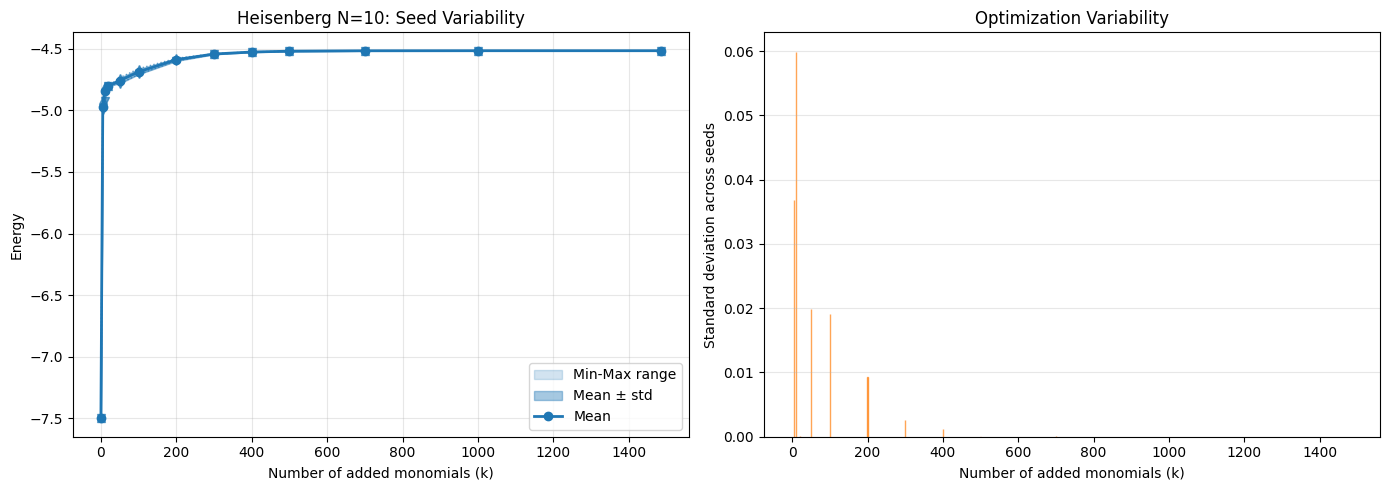

In [16]:
# Plot seed comparison: mean ± std and variability across seeds
from plots import plot_optimization_seeds_comparison

_ = plot_optimization_seeds_comparison(
    model="heisenberg",
    N=10,
    boundary="periodic",
    start_level=1,
    end_level=2,
    end_basis="heisenberg_simple",
    method="pt",
)

### Random Sampling Baseline

To validate that the optimization is actually finding better solutions than random chance, we run a **random sampling baseline**. This picks k monomials randomly (without any optimization) and evaluates the SDP.

#### Running Random Sampling

```bash
# Run random sampling with the same settings as optimization
python -m spins_sdp.scripts.optimization_sweep \
    --model heisenberg --N 4 --boundary periodic \
    --start-level 1 --end-level 2 \
    --method random \
    --k-max 16 --num-seeds 10
```

The random baseline uses `--method random` and evaluates each random selection once (no optimization steps).

In [ ]:
# Run random sampling baseline with all symmetries
from spins_sdp.scripts import optimization_sweep

optimization_sweep.main([
    "--model", "heisenberg",
    "--N", "10",
    "--boundary", "periodic",
    "--start-level", "1",
    "--end-level", "2",
    "--end-basis", "heisenberg_simple",
    "--method", "random",  # Random sampling
    "--ks", "0", "5",
    "10",
    "20",
    "50",
    "100",
    "200",
    "300",
    "400",
    "500",
    "700",
    "1000",
    "1485",
    
    # "10", "20", "40", "80", "100", "150", "200", "250", "300", "350", "400",
    "--num-seeds", "10",   # More seeds for statistical power
    "--resume",
    "--use-all-symmetries",  # Use all symmetries for Heisenberg
])

### Optimization vs Random Comparison

**Is optimization actually finding better solutions than random sampling?**

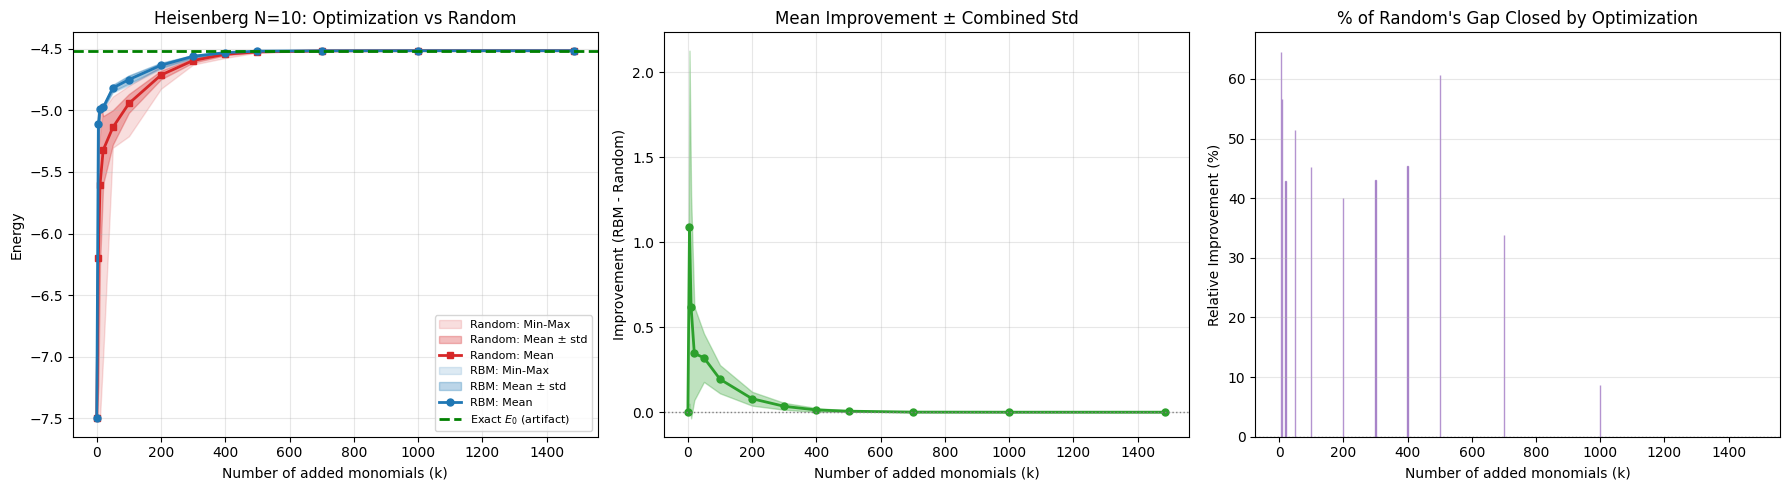

In [17]:
# Compare optimization vs random sampling
from plots import plot_optimization_vs_random

comparison = plot_optimization_vs_random(
    model="heisenberg",
    N=10,
    boundary="periodic",
    start_level=1,
    end_basis="heisenberg_simple",
    optimization_method="rbm",  # Compare RBM optimization vs random
)

### Multi-Method Comparison

When we have multiple optimization methods (SA, PT, BO) plus random sampling, we can compare them all at once:

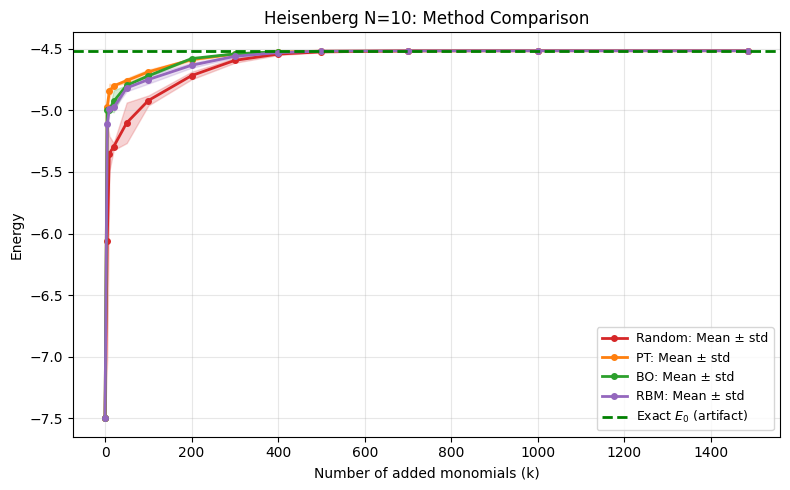

Methods compared: ['random', 'pt', 'bo', 'rbm']


In [10]:
# Compare all available methods
from plots import plot_method_comparison

try:
    method_comparison = plot_method_comparison(
        model="heisenberg",
        N=10,
        boundary="periodic",
        start_level=1,
        end_basis="heisenberg_simple",
        methods=["random", "pt", "bo", "rbm"],  # Will skip methods without data
    )
    print(f"Methods compared: {method_comparison['methods']}")
except FileNotFoundError as e:
    print(f"Note: {e}")
    print("Run more optimization methods to see a full comparison.")

### Timing Analysis

How long does each optimization take?

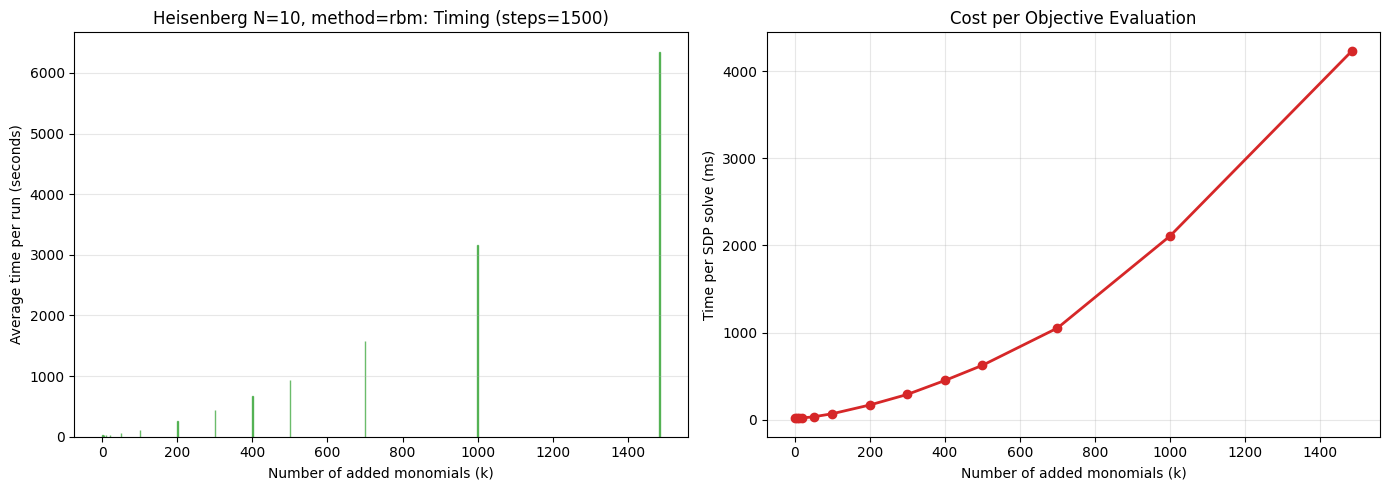

In [1]:
# Plot timing information
from plots import plot_optimization_timing

_ = plot_optimization_timing(
    model="heisenberg",
    N=10,
    boundary="periodic",
    start_level=1,
    end_basis="heisenberg_simple",
    method="rbm",
)

In [4]:
from pathlib import Path
from spins_sdp.scripts.optimization_sweep import get_best_per_k

# Accepts either Path or string, but Path keeps things explicit.
# Note: optimization artifacts live under spins_sdp/results/ by default.
best_by_k = get_best_per_k(Path('spins_sdp/results/spin_optimization_sweep/v1/1404ded0920fe552'))

# Show a quick summary
print(f"Loaded {len(best_by_k)} k-values")
print(f"Largest k present: {max(best_by_k) if best_by_k else None}")

for k, result in best_by_k.items():
    print(result)

Loaded 13 k-values
Largest k present: 1485
{'best_value': -7.499999999999913, 'seed': 42, 'mask': array([False, False, False, ..., False, False, False], shape=(1485,)), 'run_idx': 0}
{'best_value': -4.918657185966291, 'seed': 44, 'mask': array([False, False, False, ..., False, False, False], shape=(1485,)), 'run_idx': 5}
{'best_value': -4.800425590267668, 'seed': 42, 'mask': array([False, False, False, ..., False, False, False], shape=(1485,)), 'run_idx': 6}
{'best_value': -4.800347865247006, 'seed': 44, 'mask': array([False, False, False, ..., False, False, False], shape=(1485,)), 'run_idx': 11}
{'best_value': -4.734913955435727, 'seed': 43, 'mask': array([False, False, False, ..., False, False, False], shape=(1485,)), 'run_idx': 13}
{'best_value': -4.661617776530358, 'seed': 44, 'mask': array([False, False, False, ..., False,  True, False], shape=(1485,)), 'run_idx': 17}
{'best_value': -4.5771485684064706, 'seed': 42, 'mask': array([ True, False, False, ..., False, False, False], sha

## Optimization Sweep Summary

The general workflow:

1. **Run Sweep** – Use `optimization_sweep` script or `compute_and_save()` function
   - Supports multiple methods:
     - `--method sa` – Simulated annealing
     - `--method pt` – Parallel tempering
     - `--method bo` – Bayesian optimization
     - `--method rbm` – RBM-based REINFORCE optimization
     - `--method random` – Random sampling baseline
   - Results are saved incrementally with `--resume` support
   - Stores selected monomials as bit-packed masks

2. **List Runs** – Use `list_optimization_runs()` to see available sweeps
   - Filter by model or method: `list_optimization_runs(method="sa")`

3. **Visualize** – Multiple plotting functions:
   - `plot_optimization_sweep()` – Main plot: LB vs k with exact energy reference
   - `plot_optimization_convergence()` – How quickly does the LB converge?
   - `plot_optimization_seeds_comparison()` – Variability across seeds
   - `plot_optimization_timing()` – Timing analysis
   - **`plot_optimization_vs_random()`** – Compare optimization vs random baseline
   - **`plot_method_comparison()`** – Compare multiple methods side-by-side

4. **Load Data** – For custom analysis:
   - `results_to_dataframe()` – Get pandas DataFrame
   - `get_best_per_k()` – Get best result per k value
   - `load_optimization_results()` – Get full data including masks

---

# DMRG Upper Bounds

The `dmrg` script runs DMRG for multiple system sizes, saving results to disk with the same artifact-based pattern as the other scripts.

**Note:** DMRG with PBC requires **N ≥ 4**. Smaller systems will be automatically skipped.

### CLI Usage

```bash
# Heisenberg model
python -m spins_sdp.scripts.dmrg \
    --model heisenberg --N-min 4 --N-max 16 \
    --chi-max 256 --mixer --resume

# Ising model
python -m spins_sdp.scripts.dmrg \
    --model ising --Ns 6 8 10 12 \
    --J 1.0 --h 0.5 \
    --chi-max 128 --mixer --resume

# Heisenberg-J2 model
python -m spins_sdp.scripts.dmrg \
    --model heisenberg_j2 --Ns 8 10 12 \
    --J2 0.5 --chi-max 512 --mixer --resume
```

### Programmatic Usage (in notebook)

In [16]:
# Note: DMRG with PBC requires N >= 4 (two-site update constraint)
from spins_sdp.scripts import dmrg

# Run DMRG for Heisenberg model
dmrg.main([
    "--model", "heisenberg",
    "--N-min", "4",
    "--N-max", "10",
    "--chi-max", "128",
    "--mixer",
    "--resume",
])

ModuleNotFoundError: No module named 'tenpy'

`list_dmrg_runs()` to see what DMRG results are stored.

In [4]:
from spins_sdp.scripts.dmrg import list_dmrg_runs

runs = list_dmrg_runs()
print(f"Found {len(runs)} DMRG run(s):\n")
for run in runs:
    print(f"  Model: {run['model']}, chi_max={run['chi_max']}, mixer={run['mixer']}")
    print(f"  N values: {run.get('Ns_present', [])}")
    print(f"  Path: {run['_run_dir']}")
    print()

Found 2 DMRG run(s):

  Model: heisenberg, chi_max=128, mixer=True
  N values: [4, 5, 6, 7, 8, 9, 10]
  Path: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_dmrg_energy_ub\v1\d6a08aa1f18196a6

  Model: heisenberg, chi_max=64, mixer=True
  N values: []
  Path: C:\Users\lmatos\Desktop\code\SpinsSDP\spins_sdp\results\spin_dmrg_energy_ub\v1\e8570fa916ecad9d



Load DMRG results for custom analysis.

In [5]:
# Load DMRG results from the most recent run
from spins_sdp.scripts.dmrg import load_dmrg_results
from pathlib import Path

run_root = Path("spins_sdp/results/spin_dmrg_energy_ub/v1")
if run_root.exists():
    run_dirs = sorted([d for d in run_root.iterdir() if d.is_dir()], 
                      key=lambda d: d.stat().st_mtime, reverse=True)
    if run_dirs:
        run_dir = run_dirs[0]
        results = load_dmrg_results(run_dir)
        
        print("DMRG Results:")
        print(f"Model: {results['meta']['model']}")
        print(f"chi_max: {results['meta']['chi_max']}, mixer: {results['meta']['mixer']}")
        print()
        print(f"{'N':>4} {'E (total)':>14} {'e (per site)':>14} {'chi_final':>10} {'time (s)':>10}")
        print("-" * 56)
        for N in sorted(results['data'].keys()):
            d = results['data'][N]
            print(f"{N:4d} {d['E']:14.8f} {d['e']:14.8f} {d['chi_final']:10d} {d['elapsed_s']:10.2f}")
else:
    print("No DMRG runs found. Run the cell above first.")

DMRG Results:
Model: heisenberg
chi_max: 128, mixer: True

   N      E (total)   e (per site)  chi_final   time (s)
--------------------------------------------------------
   4    -2.00000000    -0.50000000          4       0.10
   5    -1.86803399    -0.37360680          4       0.90
   6    -2.80277564    -0.46712927          8       0.21
   7    -2.85517926    -0.40788275          8      47.22
   8    -3.65109341    -0.45638668         16       0.35
   9    -3.79729978    -0.42192220         16       0.60
  10    -4.51544635    -0.45154464         32       0.52
